In [1]:
import torch
import torch.nn as nn
from torch.functional import F
import matplotlib.pyplot as plt

In [2]:
with open("names.txt", "r") as file:
    names = file.read().split('\n')

chars = sorted(set(''.join(names) + '.'))
vocab_size = len(chars) + 1
idx2char = {idx:char for idx, char in enumerate(chars, start=1)}
char2idx = {char:idx for idx, char in idx2char.items()}

def encode(name: str) -> list[int]:
    return [char2idx[char] for char in name]

def decode(ids: list[int]) -> str:
    return ''.join(idx2char[i] for i in ids)

In [3]:
X = [encode('.' + name) for name in names]
y = [encode(name + '.') for name in names]
X[:5]

[[1, 6, 14, 14, 2],
 [1, 16, 13, 10, 23, 10, 2],
 [1, 2, 23, 2],
 [1, 10, 20, 2, 3, 6, 13, 13, 2],
 [1, 20, 16, 17, 9, 10, 2]]

In [4]:
from sklearn.model_selection import train_test_split

Xtr, Xts, Ytr, Yts = train_test_split(X, y, test_size=0.2)

In [5]:
from torch.utils.data import Dataset, DataLoader

class NamesDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

Dtr = NamesDataset(Xtr, Ytr)
Dts = NamesDataset(Xts, Yts)

In [6]:
from torch.nn.utils.rnn import pad_sequence

In [7]:
def collate_fn(batch):
    X, Y = zip(*batch)
    return pad_sequence([torch.tensor(x) for x in X], batch_first=True), \
            pad_sequence([torch.tensor(y) for y in Y], batch_first=True)

Dltr = DataLoader(Dtr, batch_size=5, shuffle=True, drop_last=True, collate_fn=collate_fn)
Dlts = DataLoader(Dts, batch_size=5, shuffle=True, drop_last=False, collate_fn=collate_fn)

In [8]:
for x, y in Dltr:
    print(x)
    print(y)
    break

tensor([[ 1, 11,  2,  4, 16,  3, 10,  0,  0],
        [ 1, 21,  6, 15, 15, 26, 20, 16, 15],
        [ 1, 20,  2, 14,  2, 19, 10,  0,  0],
        [ 1,  8,  2, 19,  6, 15,  0,  0,  0],
        [ 1,  2, 13, 10, 12,  0,  0,  0,  0]])
tensor([[11,  2,  4, 16,  3, 10,  1,  0,  0],
        [21,  6, 15, 15, 26, 20, 16, 15,  1],
        [20,  2, 14,  2, 19, 10,  1,  0,  0],
        [ 8,  2, 19,  6, 15,  1,  0,  0,  0],
        [ 2, 13, 10, 12,  1,  0,  0,  0,  0]])


In [9]:
class NamesDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

Dtr = NamesDataset(Xtr, Ytr)
Dts = NamesDataset(Xts, Yts)

In [10]:
def collate_fn(batch):
    X, Y = zip(*batch)
    return pad_sequence([torch.tensor(x) for x in X], batch_first=True), \
            pad_sequence([torch.tensor(y) for y in Y], batch_first=True)

Dltr = DataLoader(Dtr, batch_size=5, shuffle=True, collate_fn=collate_fn, drop_last=True)
Dlts = DataLoader(Dts, batch_size=5, shuffle=True, collate_fn=collate_fn, drop_last=False)

In [11]:
class CharRNN(nn.Module):
    def __init__(self, vocab_size, n_embd, hidden_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, n_embd)
        self.rnn = nn.RNN(n_embd, hidden_dim)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        x = self.emb(x)
        out, h = self.rnn(x)
        logits = self.fc(out)
        return logits

model = CharRNN(vocab_size=vocab_size, n_embd=16, hidden_dim=16)
optimizer = torch.optim.AdamW(model.parameters())

In [12]:
lossi = []
eval_lossi = []

for epoch in range(11):
    epoch_lossi = []
    for x, y in Dltr:
        logits = model(x)
        B, T, C = logits.shape
        logits = logits.view(B*T, C)
        y = y.view(B*T)
        loss = F.cross_entropy(logits, y, ignore_index=0)
        epoch_lossi.append(loss.data)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    lossi.append(torch.tensor(epoch_lossi).mean().data)

    epoch_lossi = []
    for x, y in Dlts:
        logits = model(x)
        B, T, C = logits.shape
        logits = logits.view(B*T, C)
        y = y.view(B*T)
        loss = F.cross_entropy(logits, y, ignore_index=0)
        epoch_lossi.append(loss.data)
        
    eval_lossi.append(torch.tensor(epoch_lossi).mean().data)

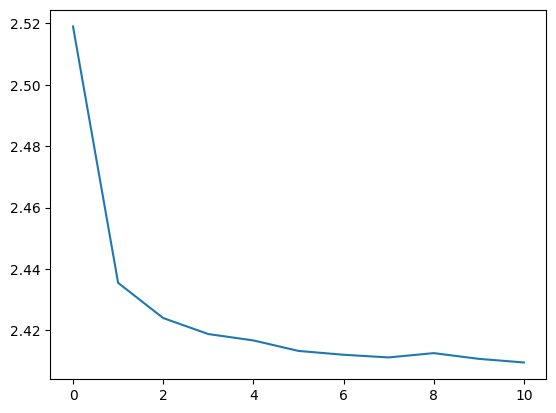

In [13]:
plt.plot(lossi)
plt.show()

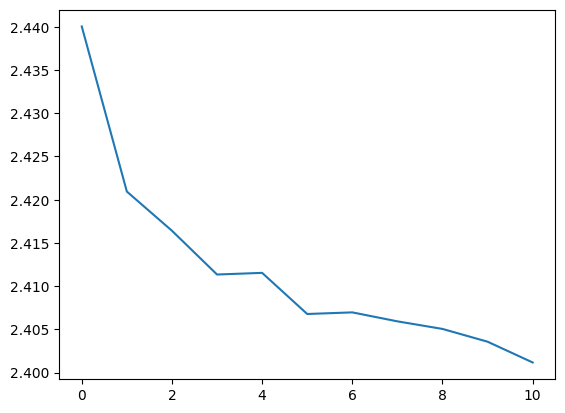

In [14]:
plt.plot(eval_lossi)
plt.show()